🧪 1. جاري إعداد بيانات القراءات الكيميائية (N, P, K, pH)...

🤖 2. بدء تدريب وتقييم الخوارزميات (Random Forest vs XGBoost)...

🌲 دقة نموذج Random Forest: 95.95%
🚀 دقة نموذج XGBoost:       95.95%


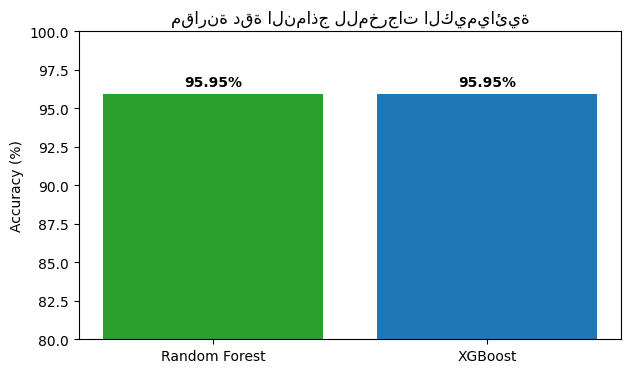

✅ تم اعتماد النموذج الأفضل: XGBoost

📋 **تقرير التوصية الكيميائية للتربة**
📥 المدخلات الكيميائية: N=85, P=50, K=50, pH=6.5
🌟 **المحصول الأنسب للزراعة**: Tomato (طماطم) (نسبة التوافق: 99.6%)

🚫 **محاصيل غير مناسبة لهذه القراءات:**
   • Chickpea (حمص)
   • Orange (برتقال)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

print("🧪 1. جاري إعداد بيانات القراءات الكيميائية (N, P, K, pH)...")

# إعداد نطاقات الخصائص الكيميائية لمختلف المحاصيل الزراعية
crop_profiles = {
    'Tomato (طماطم)': {'N': (70, 110), 'P': (40, 70), 'K': (40, 60), 'pH': (6.0, 6.8)},
    'Potato (بطاطس)': {'N': (40, 70), 'P': (40, 60), 'K': (45, 60), 'pH': (5.0, 6.5)},
    'Rice (أرز)': {'N': (60, 100), 'P': (35, 60), 'K': (35, 45), 'pH': (5.5, 6.8)},
    'Orange (برتقال)': {'N': (15, 40), 'P': (5, 30), 'K': (5, 25), 'pH': (6.0, 7.5)},
    'Chickpea (حمص)': {'N': (20, 50), 'P': (55, 80), 'K': (75, 85), 'pH': (6.0, 7.8)},
    'Maize (ذرة)': {'N': (60, 100), 'P': (35, 60), 'K': (15, 25), 'pH': (5.8, 7.0)},
    'Cotton (قطن)': {'N': (100, 140), 'P': (35, 60), 'K': (15, 25), 'pH': (6.0, 8.0)}
}

# توليد مجموعة البيانات
np.random.seed(42)
data = []
for crop, bounds in crop_profiles.items():
    for _ in range(300):
        n = np.random.uniform(*bounds['N']) + np.random.normal(0, 2)
        p = np.random.uniform(*bounds['P']) + np.random.normal(0, 2)
        k = np.random.uniform(*bounds['K']) + np.random.normal(0, 2)
        ph = np.random.uniform(*bounds['pH']) + np.random.normal(0, 0.1)
        data.append([n, p, k, ph, crop])

df = pd.DataFrame(data, columns=['N', 'P', 'K', 'pH', 'Crop'])

X = df[['N', 'P', 'K', 'pH']]
y = df['Crop']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 🤖 2. تدريب وتقييم الخوارزميات
print("\n🤖 2. بدء تدريب وتقييم الخوارزميات (Random Forest vs XGBoost)...")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred) * 100

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred) * 100

# 📊 3. عرض نتائج المقارنة
print("\n==================================================")
print(f"🌲 دقة نموذج Random Forest: {rf_acc:.2f}%")
print(f"🚀 دقة نموذج XGBoost:       {xgb_acc:.2f}%")
print("==================================================")

# رسم بياني للمقارنة
plt.figure(figsize=(7, 4))
models_acc = {'Random Forest': rf_acc, 'XGBoost': xgb_acc}
plt.bar(models_acc.keys(), models_acc.values(), color=['#2ca02c', '#1f77b4'])
plt.ylabel('Accuracy (%)')
plt.title('مقارنة دقة النماذج للمخرجات الكيميائية')
plt.ylim(80, 100)
for i, v in enumerate(models_acc.values()):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

# اعتماد النموذج الأفضل
best_model = xgb_model if xgb_acc >= rf_acc else rf_model
best_name = "XGBoost" if xgb_acc >= rf_acc else "Random Forest"
print(f"✅ تم اعتماد النموذج الأفضل: {best_name}")

# 🔮 4. دالة التنبؤ بالتوصيات الكيميائية
def predict_crop_recommendation(n, p, k, ph):
    sample = pd.DataFrame([[n, p, k, ph]], columns=['N', 'P', 'K', 'pH'])
    pred_idx = best_model.predict(sample)[0]
    probs = best_model.predict_proba(sample)[0]

    recommended_crop = le.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx] * 100

    # استخراج المحاصيل غير المناسبة
    sorted_indices = np.argsort(probs)
    unsuitable_indices = sorted_indices[:2]
    unsuitable_crops = le.inverse_transform(unsuitable_indices)

    print("\n==================================================")
    print("📋 **تقرير التوصية الكيميائية للتربة**")
    print("==================================================")
    print(f"📥 المدخلات الكيميائية: N={n}, P={p}, K={k}, pH={ph}")
    print(f"🌟 **المحصول الأنسب للزراعة**: {recommended_crop} (نسبة التوافق: {confidence:.1f}%)")
    print("\n🚫 **محاصيل غير مناسبة لهذه القراءات:**")
    for crop in unsuitable_crops:
        print(f"   • {crop}")
    print("==================================================\n")

# تجربة قراءة عينة (N=85, P=50, K=50, pH=6.5)
predict_crop_recommendation(n=85, p=50, k=50, ph=6.5)